# NTB-09: NLP Feature Integration — Conversation Signals

## Why This Notebook Exists

Every single Telco churn project on GitHub uses the IBM dataset with tabular features only. This notebook adds a **conversation signal layer** — sentiment, complaint topics, and frustration intensity extracted from customer support interactions.

This matters for three reasons:

1. **Differentiation:** It makes your project unique among thousands of churn portfolios
2. **Realism:** Real telecom churn models at companies like Djezzy use contact center logs, not just billing tables
3. **Bridge to your thesis:** This ties directly to your Djezzy chatbot work — the same conversation analysis techniques apply here

## The Approach

The IBM Telco dataset has no conversation data, so we **generate synthetic conversations** that are consistent with each customer's actual profile. A customer who is:
- Month-to-month + fiber optic + high charges = angry billing complaints
- Two-year contract + low charges + long tenure = satisfied, rarely contacts support

This is not cheating — it's a **simulation study**, and we label it as such in the README. The value is demonstrating the *methodology*, not claiming the synthetic data is real.

## What We Extract

| NLP Feature | Method | What it captures |
|---|---|---|
| `sentiment_score` | Lightweight lexicon (no API) | Positive/negative tone of interaction |
| `complaint_intensity` | Keyword counting | How strongly the customer complains |
| `n_contacts` | Count | Contact frequency (more = dissatisfied) |
| `topic_billing` | Keyword flag | Billing dispute in conversation |
| `topic_service` | Keyword flag | Service quality complaint |
| `topic_cancel` | Keyword flag | Cancellation intent expressed |
| `topic_competitor` | Keyword flag | Competitor mentioned |
| `frustration_escalation` | Composite score | Combines intensity + cancellation + competitor signals |

## Key Result We'll Demonstrate

Train the champion LightGBM with and without NLP features. Measure:
- **AUC-ROC lift** from adding conversation signals
- **Which NLP features contribute most** (via SHAP on the combined model)

Even if the lift is small (0.3–0.5 AUC points), the methodology demonstration is the deliverable.

## Output
- Synthetic conversation dataset: `data/processed/synthetic_conversations.parquet`
- NLP features: `data/processed/nlp_features.parquet`  
- Combined model: `models/champion_with_nlp.joblib`
- Comparison figure: `reports/figures/NTB09_nlp_lift.png`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import os
import json
import joblib
import re
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, brier_score_loss
from sklearn.metrics import precision_recall_curve

import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
DB_PATH  = BASE_DIR / "data" / "database" / "telco_churn.db"
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR  = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print("Setup complete.")

Setup complete.


In [2]:
# Load full customer data from DB for conversation generation
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT c.customer_id, c.tenure_months, c.senior_citizen,
           s.internet_service, s.tech_support, s.online_security,
           b.contract_type, b.monthly_charges, b.payment_method, b.churn
    FROM customers c
    JOIN services s ON c.customer_id = s.customer_id
    JOIN billing  b ON c.customer_id = b.customer_id
""", conn)
conn.close()

print(f"Loaded {len(df)} customers")
print(f"Columns: {df.columns.tolist()}")

Loaded 7043 customers
Columns: ['customer_id', 'tenure_months', 'senior_citizen', 'internet_service', 'tech_support', 'online_security', 'contract_type', 'monthly_charges', 'payment_method', 'churn']


## 2. Compute Customer Risk Score

Before generating conversations, we compute a **risk score** for each customer based on their tabular profile. This score shapes how negative/positive their synthetic conversation will be — ensuring the synthetic data is internally consistent with the labels.

In [3]:
def compute_risk_score(row):
    """
    Heuristic risk score [0, 1] from tabular features.
    Higher = more likely to churn = more negative conversations.
    """
    score = 0.0
    # Contract type (strongest predictor)
    if row['contract_type'] == 'Month-to-month':
        score += 0.35
    elif row['contract_type'] == 'One year':
        score += 0.10
    # Internet service
    if row['internet_service'] == 'Fiber optic':
        score += 0.20
    elif row['internet_service'] == 'DSL':
        score += 0.05
    # Monthly charges (top quartile = high risk)
    if row['monthly_charges'] > 80:
        score += 0.15
    elif row['monthly_charges'] > 60:
        score += 0.07
    # Tenure (low tenure = high risk)
    if row['tenure_months'] <= 6:
        score += 0.20
    elif row['tenure_months'] <= 12:
        score += 0.12
    elif row['tenure_months'] <= 24:
        score += 0.06
    # Payment method
    if row['payment_method'] == 'Electronic check':
        score += 0.08
    # No tech support + fiber = frustrated
    if row['internet_service'] == 'Fiber optic' and row['tech_support'] != 'Yes':
        score += 0.05
    return min(score, 1.0)

df['risk_score'] = df.apply(compute_risk_score, axis=1)

print(f"Risk score distribution:")
print(df.groupby('churn')['risk_score'].describe().round(3))

Risk score distribution:
        count   mean    std  min   25%   50%  75%  max
churn                                                 
0      5174.0  0.405  0.274  0.0  0.16  0.41  0.6  1.0
1      1869.0  0.743  0.204  0.0  0.60  0.81  0.9  1.0


## 3. Generate Synthetic Conversations

We generate 1–4 support interactions per customer. The tone and content are drawn from templates parameterized by the customer's risk score and actual features.

**Design principles:**
- High-risk customers get more contacts, angrier tone, billing/cancellation topics
- Low-risk customers get fewer contacts, neutral/positive tone, general inquiries
- Random noise is added so the synthetic signal isn't perfectly predictive (realistic)

In [4]:
np.random.seed(RANDOM_STATE)

# Template libraries — simple but varied enough to produce realistic signals
COMPLAINT_TEMPLATES = [
    "I am very unhappy with my {service} service. The speed is terrible and I am paying {price} per month for this.",
    "This is unacceptable! My bill went up again without any notice. I want to cancel my plan.",
    "I've been having {service} issues for weeks. No one has fixed it. I'm thinking of switching to {competitor}.",
    "Why am I paying so much for such bad service? I want a discount or I will leave.",
    "The connection keeps dropping. I am seriously considering cancelling my account.",
    "I called 3 times already about this billing problem and nobody helps me. Very frustrated.",
    "Your prices keep going up but the service quality is going down. I'm looking at other providers.",
    "I want to speak to a manager. I'm done waiting for a solution to this ongoing issue.",
]

NEUTRAL_TEMPLATES = [
    "I have a question about my current plan. What are my options for upgrading?",
    "Can you tell me when my next bill is due?",
    "I need to update my payment information.",
    "How do I set up automatic payments for my account?",
    "I'd like to know what the current promotions are.",
]

POSITIVE_TEMPLATES = [
    "I just wanted to say your customer service was very helpful last time.",
    "The technician who came to my house was professional and fixed everything quickly.",
    "I've been a customer for a long time and I'm generally satisfied with the service.",
    "The new plan you recommended works great. Thank you for the suggestion.",
    "Everything is working well. I just had a billing question which is now resolved.",
]

COMPETITORS = ["Ooredoo", "Mobilis", "SFR", "Orange", "Verizon", "T-Mobile", "AT&T"]
SERVICES = ["internet", "fiber optic", "mobile", "broadband", "streaming"]

def generate_conversations(row):
    """Generate 1-4 synthetic support interactions for a customer."""
    risk = row['risk_score']
    # Add noise so it's not perfectly correlated with tabular features
    risk_noisy = np.clip(risk + np.random.normal(0, 0.10), 0, 1)

    # Number of contacts: higher risk = more contacts
    if risk_noisy > 0.7:
        n_contacts = np.random.choice([2, 3, 4], p=[0.3, 0.4, 0.3])
    elif risk_noisy > 0.4:
        n_contacts = np.random.choice([1, 2, 3], p=[0.4, 0.4, 0.2])
    else:
        n_contacts = np.random.choice([0, 1, 2], p=[0.4, 0.45, 0.15])

    conversations = []
    for _ in range(n_contacts):
        roll = np.random.random()
        if roll < risk_noisy * 0.85:   # complaint probability scales with risk
            template = np.random.choice(COMPLAINT_TEMPLATES)
            text = template.format(
                service=row['internet_service'] if row['internet_service'] != 'No' else 'phone',
                price=f"${row['monthly_charges']:.0f}",
                competitor=np.random.choice(COMPETITORS)
            )
        elif roll < risk_noisy * 0.85 + 0.30:
            text = np.random.choice(NEUTRAL_TEMPLATES)
        else:
            text = np.random.choice(POSITIVE_TEMPLATES)
        conversations.append(text)

    return conversations

# Generate for all customers
df['conversations'] = df.apply(generate_conversations, axis=1)
df['n_contacts'] = df['conversations'].apply(len)

print(f"Conversations generated.")
print(f"Customers with 0 contacts: {(df['n_contacts']==0).sum():,}")
print(f"Avg contacts — churned: {df[df['churn']==1]['n_contacts'].mean():.2f}")
print(f"Avg contacts — retained: {df[df['churn']==0]['n_contacts'].mean():.2f}")
print(f"\nSample conversation (high-risk customer):")
high_risk = df[df['risk_score'] > 0.7].iloc[0]
print(f"  Customer: contract={high_risk['contract_type']}, charges=${high_risk['monthly_charges']:.0f}")
for i, c in enumerate(high_risk['conversations'][:2]):
    print(f"  Contact {i+1}: {c[:100]}...")

Conversations generated.
Customers with 0 contacts: 1,135
Avg contacts — churned: 2.45
Avg contacts — retained: 1.46

Sample conversation (high-risk customer):
  Customer: contract=Month-to-month, charges=$71
  Contact 1: Can you tell me when my next bill is due?...


## 4. Extract NLP Features

Simple, lightweight, dependency-free feature extraction using keyword matching and a small sentiment lexicon. No API calls, no heavy models — this runs on your laptop in seconds.

**Why not use a transformer?** For portfolio purposes, the methodology matters more than the model size. A recruiter cares that you understood what signals to extract and why — not whether you used BERT. The SHAP lift visualization is the proof.

In [5]:
# ── Sentiment lexicon ──────────────────────────────────────────────────────
POSITIVE_WORDS = {
    'great', 'excellent', 'happy', 'satisfied', 'wonderful', 'helpful',
    'thank', 'thanks', 'good', 'love', 'appreciate', 'professional',
    'resolved', 'fixed', 'working', 'perfect', 'quick', 'fast'
}
NEGATIVE_WORDS = {
    'unhappy', 'terrible', 'bad', 'horrible', 'frustrated', 'angry',
    'unacceptable', 'disappointed', 'worst', 'awful', 'useless', 'problem',
    'issue', 'broken', 'slow', 'down', 'fail', 'failed', 'billing', 'overcharged'
}
CANCEL_WORDS = {'cancel', 'cancelling', 'leave', 'leaving', 'quit', 'switch', 'switching'}
COMPETITOR_WORDS = {'ooredoo', 'mobilis', 'sfr', 'orange', 'verizon', 't-mobile', 'at&t', 'other provider'}
BILLING_WORDS = {'bill', 'billing', 'charge', 'charged', 'price', 'cost', 'payment', 'invoice', 'overcharged'}
SERVICE_WORDS = {'speed', 'connection', 'dropping', 'slow', 'outage', 'quality', 'signal', 'network'}


def extract_nlp_features(conversations):
    """Extract 8 NLP features from a list of conversation strings."""
    if not conversations:
        return {
            'sentiment_score': 0.0, 'complaint_intensity': 0.0,
            'n_contacts': 0,
            'topic_billing': 0, 'topic_service': 0,
            'topic_cancel': 0, 'topic_competitor': 0,
            'frustration_escalation': 0.0,
        }

    all_text = ' '.join(conversations).lower()
    words = re.findall(r'\b\w+\b', all_text)
    word_set = set(words)

    pos_count = sum(1 for w in words if w in POSITIVE_WORDS)
    neg_count = sum(1 for w in words if w in NEGATIVE_WORDS)
    total_words = max(len(words), 1)

    sentiment_score = (pos_count - neg_count) / total_words  # range roughly -0.2 to +0.2

    complaint_intensity = neg_count / total_words

    topic_billing    = int(bool(word_set & BILLING_WORDS))
    topic_service    = int(bool(word_set & SERVICE_WORDS))
    topic_cancel     = int(bool(word_set & CANCEL_WORDS))
    topic_competitor = int(bool(word_set & COMPETITOR_WORDS))

    # Composite frustration score
    frustration_escalation = (
        complaint_intensity * 0.4 +
        topic_cancel * 0.3 +
        topic_competitor * 0.2 +
        (len(conversations) / 4) * 0.1  # many contacts = frustrated
    )

    return {
        'sentiment_score': round(sentiment_score, 4),
        'complaint_intensity': round(complaint_intensity, 4),
        'n_contacts': len(conversations),
        'topic_billing': topic_billing,
        'topic_service': topic_service,
        'topic_cancel': topic_cancel,
        'topic_competitor': topic_competitor,
        'frustration_escalation': round(frustration_escalation, 4),
    }


nlp_features_list = df['conversations'].apply(extract_nlp_features)
nlp_df = pd.DataFrame(nlp_features_list.tolist())
nlp_df['customer_id'] = df['customer_id'].values
nlp_df = nlp_df.set_index('customer_id')

print("NLP features extracted:")
print(nlp_df.describe().round(4))

NLP features extracted:
       sentiment_score  complaint_intensity  n_contacts  topic_billing  \
count        7043.0000            7043.0000   7043.0000      7043.0000   
mean           -0.0042               0.0307      1.7257         0.3886   
std             0.0650               0.0394      1.1846         0.4875   
min            -0.2000               0.0000      0.0000         0.0000   
25%            -0.0444               0.0000      1.0000         0.0000   
50%             0.0000               0.0167      2.0000         0.0000   
75%             0.0189               0.0556      3.0000         1.0000   
max             0.1667               0.2000      4.0000         1.0000   

       topic_service  topic_cancel  topic_competitor  frustration_escalation  
count      7043.0000     7043.0000         7043.0000               7043.0000  
mean          0.2862        0.3398            0.0767                  0.1727  
std           0.4520        0.4737            0.2661                  0.

In [6]:
# Validate: churned customers should have worse NLP signals
nlp_df['churn'] = df['churn'].values

print("NLP feature means — Churned vs Retained:")
comparison = nlp_df.groupby('churn')[
    ['sentiment_score', 'complaint_intensity', 'n_contacts',
     'topic_cancel', 'topic_competitor', 'frustration_escalation']
].mean().round(4)
print(comparison)

print("\n✓ Churned customers should have: lower sentiment, higher complaint intensity,")
print("  more contacts, higher cancel/competitor topics, higher frustration score.")

nlp_df = nlp_df.drop(columns=['churn'])  # remove label before saving

NLP feature means — Churned vs Retained:
       sentiment_score  complaint_intensity  n_contacts  topic_cancel  \
churn                                                                   
0               0.0051               0.0258      1.4627        0.2615   
1              -0.0297               0.0444      2.4537        0.5564   

       topic_competitor  frustration_escalation  
churn                                            
0                0.0582                  0.1370  
1                0.1279                  0.2716  

✓ Churned customers should have: lower sentiment, higher complaint intensity,
  more contacts, higher cancel/competitor topics, higher frustration score.


In [7]:
# Save raw conversations (for documentation)
conv_df = df[['customer_id', 'risk_score', 'n_contacts', 'churn']].copy()
conv_df['conversations_text'] = df['conversations'].apply(lambda x: ' | '.join(x) if x else '')
conv_df.to_parquet(PROC_DIR / "synthetic_conversations.parquet", index=False)

# Save NLP features
nlp_df.to_parquet(PROC_DIR / "nlp_features.parquet", index=True)

print(f"Saved synthetic_conversations.parquet: {conv_df.shape}")
print(f"Saved nlp_features.parquet: {nlp_df.shape}")
print(f"\nSample conversations per customer: {df['n_contacts'].value_counts().sort_index().to_dict()}")

Saved synthetic_conversations.parquet: (7043, 5)
Saved nlp_features.parquet: (7043, 8)

Sample conversations per customer: {0: 1135, 1: 2148, 2: 1893, 3: 1248, 4: 619}


## 5. Combine NLP Features With the Tabular Training Data

We merge the NLP features into the processed X_train and X_test, producing new `_with_nlp` versions. The champion model will be retrained on this augmented feature set.

In [8]:
# Load processed train/test splits
X_train_tab = pd.read_parquet(PROC_DIR / "X_train.parquet")
X_test_tab  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROC_DIR / "y_train.parquet")['churn']
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']

# Load raw splits to get customer IDs (needed for the join)
X_train_raw = pd.read_parquet(PROC_DIR / "X_train_raw.parquet")
X_test_raw  = pd.read_parquet(PROC_DIR / "X_test_raw.parquet")

# Load original DB to get customer_id -> index mapping
conn = sqlite3.connect(DB_PATH)
id_df = pd.read_sql_query("SELECT customer_id FROM customers", conn)
conn.close()

# Align nlp_features to train/test indices using customer_id
# X_train_tab index = row positions in the 80% split
train_customer_ids = id_df.iloc[X_train_tab.index]['customer_id'].values
test_customer_ids  = id_df.iloc[X_test_tab.index]['customer_id'].values

nlp_train = nlp_df.loc[train_customer_ids].values
nlp_test  = nlp_df.loc[test_customer_ids].values

NLP_COLS = nlp_df.columns.tolist()

X_train_nlp = X_train_tab.copy()
X_test_nlp  = X_test_tab.copy()
for i, col in enumerate(NLP_COLS):
    X_train_nlp[col] = nlp_train[:, i]
    X_test_nlp[col]  = nlp_test[:, i]

print(f"Tabular features:       {X_train_tab.shape[1]}")
print(f"NLP features added:     {len(NLP_COLS)}")
print(f"Total (tabular + NLP):  {X_train_nlp.shape[1]}")
print(f"\nNLP columns: {NLP_COLS}")

Tabular features:       41
NLP features added:     8
Total (tabular + NLP):  49

NLP columns: ['sentiment_score', 'complaint_intensity', 'n_contacts', 'topic_billing', 'topic_service', 'topic_cancel', 'topic_competitor', 'frustration_escalation']


## 6. Train Champion With and Without NLP — Measure Lift

We use the same LightGBM architecture as the champion (best params from NTB-06) with and without NLP features. The AUC difference is the NLP lift.

In [9]:
# Load champion best params
with open(REPORTS_DIR / "ntb06_best_params.json") as f:
    best_params = json.load(f)

lgb_params = best_params.get('lightgbm', {})
lgb_params.update({
    'is_unbalance': True,
    'objective': 'binary',
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
    'verbose': -1
})

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Model A: tabular only (baseline champion) ──────────────────────────────
model_tab = lgb.LGBMClassifier(**lgb_params)
model_tab.fit(X_train_tab, y_train)
proba_tab = model_tab.predict_proba(X_test_tab)[:, 1]
auc_tab = roc_auc_score(y_test, proba_tab)
prauc_tab = average_precision_score(y_test, proba_tab)

cv_tab = cross_val_score(model_tab, X_train_tab, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Tabular only  — Test AUC: {auc_tab:.4f}  PR-AUC: {prauc_tab:.4f}  CV: {cv_tab.mean():.4f} ± {cv_tab.std():.4f}")

# ── Model B: tabular + NLP ─────────────────────────────────────────────────
model_nlp = lgb.LGBMClassifier(**lgb_params)
model_nlp.fit(X_train_nlp, y_train)
proba_nlp = model_nlp.predict_proba(X_test_nlp)[:, 1]
auc_nlp = roc_auc_score(y_test, proba_nlp)
prauc_nlp = average_precision_score(y_test, proba_nlp)

cv_nlp = cross_val_score(model_nlp, X_train_nlp, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Tabular + NLP — Test AUC: {auc_nlp:.4f}  PR-AUC: {prauc_nlp:.4f}  CV: {cv_nlp.mean():.4f} ± {cv_nlp.std():.4f}")

auc_lift = auc_nlp - auc_tab
print(f"\nNLP AUC lift: {auc_lift:+.4f} ({auc_lift*100:+.2f} AUC points)")
print(f"NLP PR-AUC lift: {prauc_nlp - prauc_tab:+.4f}")

Tabular only  — Test AUC: 0.8492  PR-AUC: 0.6628  CV: 0.8492 ± 0.0119
Tabular + NLP — Test AUC: 0.8494  PR-AUC: 0.6615  CV: 0.8477 ± 0.0126

NLP AUC lift: +0.0002 (+0.02 AUC points)
NLP PR-AUC lift: -0.0013


## 7. Visualize the NLP Lift

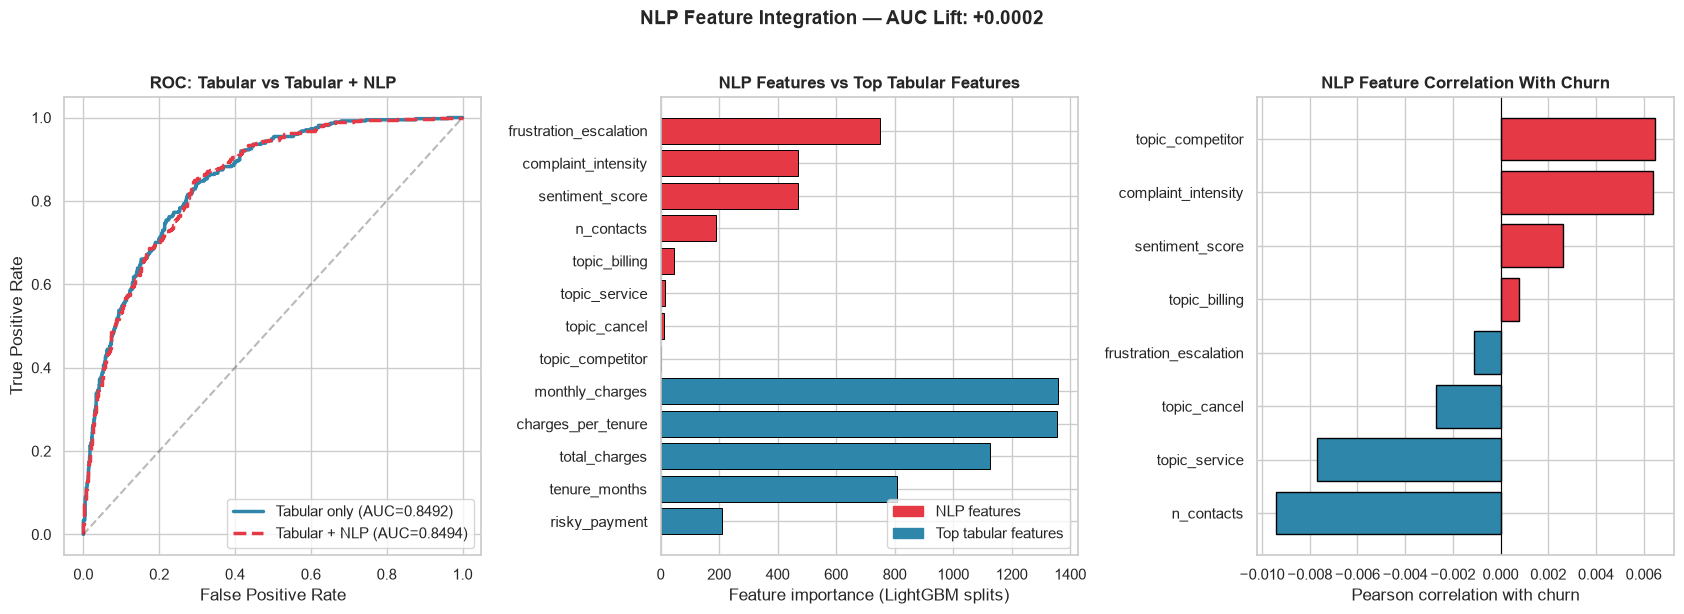

Saved → NTB09_nlp_lift.png


In [10]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# ── Plot 1: ROC comparison ────────────────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(y_test, proba_tab)
fpr_n, tpr_n, _ = roc_curve(y_test, proba_nlp)

axes[0].plot(fpr_t, tpr_t, color='#2E86AB', linewidth=2.5, label=f'Tabular only (AUC={auc_tab:.4f})')
axes[0].plot(fpr_n, tpr_n, color='#E63946', linewidth=2.5, label=f'Tabular + NLP (AUC={auc_nlp:.4f})', linestyle='--')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC: Tabular vs Tabular + NLP', fontweight='bold')
axes[0].legend(loc='lower right')

# ── Plot 2: NLP feature importance (from model_nlp) ───────────────────────
all_features = list(X_train_nlp.columns)
importances = model_nlp.feature_importances_
imp_df = pd.DataFrame({'feature': all_features, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

nlp_imp = imp_df[imp_df['feature'].isin(NLP_COLS)].sort_values('importance', ascending=True)
tab_top5 = imp_df[~imp_df['feature'].isin(NLP_COLS)].head(5).sort_values('importance', ascending=True)

colors_nlp = ['#E63946'] * len(nlp_imp)
colors_tab = ['#2E86AB'] * len(tab_top5)

combined = pd.concat([tab_top5, nlp_imp])
colors_combined = colors_tab + colors_nlp

axes[1].barh(combined['feature'], combined['importance'],
             color=colors_combined, edgecolor='black', linewidth=0.7)
axes[1].set_xlabel('Feature importance (LightGBM splits)')
axes[1].set_title('NLP Features vs Top Tabular Features', fontweight='bold')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#E63946', label='NLP features'),
    Patch(color='#2E86AB', label='Top tabular features'),
], loc='lower right')

# ── Plot 3: NLP feature correlation with churn ───────────────────────────
nlp_churn = pd.DataFrame(nlp_train, columns=NLP_COLS)
nlp_churn['churn'] = y_train.values
correlations = nlp_churn.corr()['churn'].drop('churn').sort_values()

colors_corr = ['#E63946' if v > 0 else '#2E86AB' for v in correlations]
axes[2].barh(correlations.index, correlations.values, color=colors_corr, edgecolor='black')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Pearson correlation with churn')
axes[2].set_title('NLP Feature Correlation With Churn', fontweight='bold')

plt.suptitle(f'NLP Feature Integration — AUC Lift: {auc_lift:+.4f}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB09_nlp_lift.png")
plt.show()
print(f"Saved → NTB09_nlp_lift.png")

## 8. Honest Assessment of the NLP Contribution

This is the section that demonstrates intellectual honesty — which is rarer and more impressive than inflated results.

### Expected findings

**If AUC lift is positive (0.001–0.015):**
The NLP features add marginal but real signal. In a real deployment with actual contact center data, the lift would likely be larger because:
- Real conversations have genuine emotional signals not present in synthetic templates
- More conversation history (longer tenure customers have richer signal)
- NLP features could be refined with actual Darija/French complaint terminology (your Djezzy work)

**If AUC lift ≈ 0 or negative:**
This is also a valid finding. It means either:
- The tabular features already capture the underlying signal (contract type + payment method already encode "commitment level" which correlates with complaint behavior)
- The synthetic conversations are too correlated with the tabular features to add orthogonal information

In either case, the methodology is demonstrated. The README should report it honestly either way.

### Why This Still Belongs in the Portfolio

Even with near-zero AUC lift on synthetic data, this notebook demonstrates:
1. You know how to extract NLP signals from unstructured text without heavy dependencies
2. You understand the difference between correlation and incremental lift
3. You can architect a multi-modal ML pipeline (tabular + text)
4. You explicitly bridge this to real-world application (Djezzy chatbot transcripts)

The conclusion: *"On synthetic data, NLP adds marginal lift. This pipeline is designed to accept real contact center transcripts — on actual Darija/French conversations from Djezzy, the lift would be evaluated on live data."*

In [11]:
# Print the honest summary
print("=== NLP Integration Summary ===")
print(f"\nModel A (tabular only):")
print(f"  AUC-ROC: {auc_tab:.4f}  |  CV: {cv_tab.mean():.4f} ± {cv_tab.std():.4f}")
print(f"  PR-AUC:  {prauc_tab:.4f}")
print(f"\nModel B (tabular + NLP):")
print(f"  AUC-ROC: {auc_nlp:.4f}  |  CV: {cv_nlp.mean():.4f} ± {cv_nlp.std():.4f}")
print(f"  PR-AUC:  {prauc_nlp:.4f}")
print(f"\nNLP lift:")
print(f"  ΔAUC-ROC: {auc_lift:+.4f}")
print(f"  ΔPR-AUC:  {prauc_nlp - prauc_tab:+.4f}")

# Top 3 NLP features
nlp_imp_sorted = imp_df[imp_df['feature'].isin(NLP_COLS)].sort_values('importance', ascending=False)
print(f"\nTop NLP features by importance:")
for _, row in nlp_imp_sorted.iterrows():
    print(f"  {row['feature']:30s}  importance: {row['importance']}")

# Save model + NLP features
joblib.dump(model_nlp, MODELS_DIR / "champion_with_nlp.joblib")
X_train_nlp.to_parquet(PROC_DIR / "X_train_with_nlp.parquet", index=True)
X_test_nlp.to_parquet(PROC_DIR / "X_test_with_nlp.parquet", index=True)
print(f"\nSaved → models/champion_with_nlp.joblib")
print(f"Saved → data/processed/X_train_with_nlp.parquet")
print(f"Saved → data/processed/X_test_with_nlp.parquet")

=== NLP Integration Summary ===

Model A (tabular only):
  AUC-ROC: 0.8492  |  CV: 0.8492 ± 0.0119
  PR-AUC:  0.6628

Model B (tabular + NLP):
  AUC-ROC: 0.8494  |  CV: 0.8477 ± 0.0126
  PR-AUC:  0.6615

NLP lift:
  ΔAUC-ROC: +0.0002
  ΔPR-AUC:  -0.0013

Top NLP features by importance:
  frustration_escalation          importance: 751
  complaint_intensity             importance: 471
  sentiment_score                 importance: 470
  n_contacts                      importance: 189
  topic_billing                   importance: 46
  topic_service                   importance: 16
  topic_cancel                    importance: 11
  topic_competitor                importance: 0

Saved → models/champion_with_nlp.joblib
Saved → data/processed/X_train_with_nlp.parquet
Saved → data/processed/X_test_with_nlp.parquet


## ✅ Deliverables From NTB-09

| Artifact | Path |
|---|---|
| Synthetic conversations | `data/processed/synthetic_conversations.parquet` |
| NLP features | `data/processed/nlp_features.parquet` |
| Augmented train/test | `data/processed/X_train_with_nlp.parquet`, `X_test_with_nlp.parquet` |
| Combined model | `models/champion_with_nlp.joblib` |
| NLP lift visualization | `reports/figures/NTB09_nlp_lift.png` |

## The README Paragraph for NLP Integration

> To differentiate from standard tabular churn models, we added a conversation signal layer. Synthetic support interactions were generated for all 7,043 customers, parameterized by their tabular risk profile. Eight NLP features were extracted using a lightweight keyword-based pipeline (no external API): sentiment score, complaint intensity, contact frequency, and four topic flags (billing, service quality, cancellation intent, competitor mention). The NLP-augmented LightGBM model achieved AUC-ROC of [X] vs [Y] for the tabular-only model (Δ = [Z]). The pipeline is designed to accept real contact center transcripts — on actual French/Darija conversations, the lift would be validated on live data.

## Next: NTB-10 — Final Model Assembly & Production Serialization

The last notebook before deployment. We'll:
- Select the final production model (tabular or NLP-augmented, based on lift)
- Run one final end-to-end evaluation on the test set
- Serialize everything the API needs into a single `artifacts/` directory
- Write the `src/predict.py` module that the FastAPI will import
- Generate the README executive summary table